# End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project — Week 3 & Week 4

### Project Objective
The objective of this project is to build an intelligent sales forecasting and demand analysis system using time series analysis, machine learning, anomaly detection, and product demand segmentation. The system forecasts future sales, identifies unusual sales patterns, segments products based on demand behavior, and presents business insights through an interactive dashboard.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Task 1 — Data Loading, Merging & Deep Exploration

In this task, the Superstore Sales dataset is loaded and explored. The dataset is checked for its structure, data types, missing values, duplicates, and date-related features for further time series analysis.

In [2]:
# Load the Superstore Sales dataset

df = pd.read_csv('train.csv')

print("Dataset loaded successfully")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Convert date columns to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Date columns converted successfully")

print(df[['Order Date', 'Ship Date']].dtypes)

Date columns converted successfully
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [4]:
# Extract time-based features from Order Date

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

# Create Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

df[['Order Date', 'Year', 'Month', 'Week Number',
    'Day of Week', 'Quarter', 'Season']].head()

,Order Date,Year,Month,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Post-Monsoon
1,2017-11-08,2017,11,45,Wednesday,4,Post-Monsoon
2,2017-06-12,2017,6,24,Monday,2,Monsoon
3,2016-10-11,2016,10,41,Tuesday,4,Post-Monsoon
4,2016-10-11,2016,10,41,Tuesday,4,Post-Monsoon


In [5]:
# Check missing values, duplicates, and data types

print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Number of Duplicate Rows:
0

Data Types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
C

In [6]:
# Handle missing values in Postal Code

df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

print("Missing values after handling:")
print(df.isnull().sum().sum())

print("\nPostal Code Data Type:")
print(df['Postal Code'].dtype)

Missing values after handling:
0

Postal Code Data Type:
int64


In [7]:
# Aggregate sales into weekly and monthly totals

weekly_sales = (
    df.set_index('Order Date')['Sales']
    .resample('W')
    .sum()
    .reset_index()
)

monthly_sales = (
    df.set_index('Order Date')['Sales']
    .resample('MS')
    .sum()
    .reset_index()
)

print("Weekly Sales Data:")
print(weekly_sales.head())

print("\nMonthly Sales Data:")
print(monthly_sales.head())

print("\nWeekly Sales Shape:", weekly_sales.shape)
print("Monthly Sales Shape:", monthly_sales.shape)

Weekly Sales Data:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914

Monthly Sales Data:
  Order Date      Sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303

Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


### Business Question 1: Which Product Category Generates the Highest Total Revenue?

In [8]:
# Calculate total sales revenue by product category

category_revenue = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print("Total Revenue by Product Category:")
print(category_revenue)

print("\nHighest Revenue Generating Category:")
print(category_revenue.idxmax())

print("Total Revenue:")
print(category_revenue.max())

Total Revenue by Product Category:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Highest Revenue Generating Category:
Technology
Total Revenue:
827455.873


**Observation:**  
Technology is the highest revenue-generating product category with total sales of approximately $827,455.87. Furniture generated approximately $728,658.58, while Office Supplies generated approximately $705,422.33. Therefore, Technology contributes the highest total revenue among all product categories.

### Business Question 2: Which Region Has the Most Consistent Sales Growth Over 4 Years?

In [9]:
# Calculate yearly sales by region

region_yearly_sales = (
    df.groupby(['Region', 'Year'])['Sales']
    .sum()
    .unstack()
)

print("Yearly Sales by Region:")
print(region_yearly_sales)

# Calculate year-over-year growth rates
region_growth = region_yearly_sales.pct_change(axis=1) * 100

print("\nYear-over-Year Sales Growth by Region (%):")
print(region_growth)

# Calculate standard deviation of growth rates
growth_consistency = region_growth.std(axis=1).sort_values()

print("\nGrowth Consistency by Region:")
print(growth_consistency)

print("\nMost Consistent Sales Growth Region:")
print(growth_consistency.idxmin())

Yearly Sales by Region:
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

Year-over-Year Sales Growth by Region (%):
Year     2015       2016       2017       2018
Region                                        
Central   NaN  -0.481292  42.224686  -2.777807
East      NaN  20.032745  16.502741  17.711823
South     NaN -32.211708  33.477643  30.607139
West      NaN  -8.360336  36.468341  35.983589

Growth Consistency by Region:
Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
dtype: float64

Most Consistent Sales Growth Region:
East


**Observation:**  
The East region shows the most consistent sales growth over the four-year period. Its year-over-year growth rates are approximately 20.03%, 16.50%, and 17.71%, with the lowest growth-rate standard deviation of 1.79 among all regions. This indicates stable and consistent sales growth compared with the Central, South, and West regions.

### Business Question 3: What Is the Average Time Between Order Date and Ship Date, and Does It Vary by Region?

In [10]:
# Calculate shipping time in days

df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

average_shipping_time = df['Shipping Days'].mean()

region_shipping_time = (
    df.groupby('Region')['Shipping Days']
    .mean()
    .sort_values()
)

print("Average Shipping Time:")
print(average_shipping_time)

print("\nAverage Shipping Time by Region:")
print(region_shipping_time)

Average Shipping Time:
3.9611224489795918

Average Shipping Time by Region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


**Observation:**
The average time between the Order Date and Ship Date is approximately 3.96 days. Shipping time varies slightly across regions. The East region has the lowest average shipping time of 3.91 days, while the Central region has the highest average shipping time of 4.07 days. However, the overall regional variation in shipping time is relatively small.


### Business Question 4: Are There Months That Consistently Show Sales Spikes Across All Years?

In [11]:
# Analyze monthly sales patterns across all years

monthly_sales_pattern = (
    df.groupby(['Year', 'Month'])['Sales']
    .sum()
    .unstack()
)

print("Monthly Sales by Year:")
print(monthly_sales_pattern)

# Calculate average monthly total sales across all years
average_monthly_sales = (
    monthly_sales_pattern
    .mean(axis=0)
    .sort_values(ascending=False)
)

print("\nAverage Monthly Total Sales Across All Years:")
print(average_monthly_sales)

print("\nMonth with Highest Average Total Sales:")
print(average_monthly_sales.idxmax())

Monthly Sales by Year:
Month          1           2           3           4           5           6   \
Year                                                                            
2015   14205.7070   4519.8920  55205.7970  27906.8550  23644.3030  34322.9356   
2016   18066.9576  11951.4110  32339.3184  34154.4685  29959.5305  23599.3740   
2017   18542.4910  22978.8150  51165.0590  38679.7670  56656.9080  39724.4860   
2018   43476.4740  19920.9974  58863.4128  35541.9101  43825.9822  48190.7277   

Month         7           8           9           10           11          12  
Year                                                                           
2015   33781.543  27117.5365  81623.5268  31453.3930   77907.6607  68167.0585  
2016   28608.259  36818.3422  63133.6060  31011.7375   75249.3995  74543.6012  
2017   38320.783  30542.2003  69193.3909  59583.0330   79066.4958  95739.1210  
2018   44825.104  62837.8480  86152.8880  77448.1312  117938.1550  83030.3888  

Average M

**Observation:**
The sales data shows a clear seasonal pattern, with higher sales generally occurring during the later months of the year. November has the highest average monthly total sales of approximately $87,540.43, followed by December at $80,370.04 and September at $75,025.85. These repeated sales spikes across multiple years indicate strong seasonality, particularly during the September to December period.


## Task 2 — Time Series Analysis & Decomposition

This task analyzes the overall monthly sales trend, decomposes the time series into trend, seasonal, and residual components, and checks whether the sales series is stationary using the Augmented Dickey-Fuller (ADF) test.

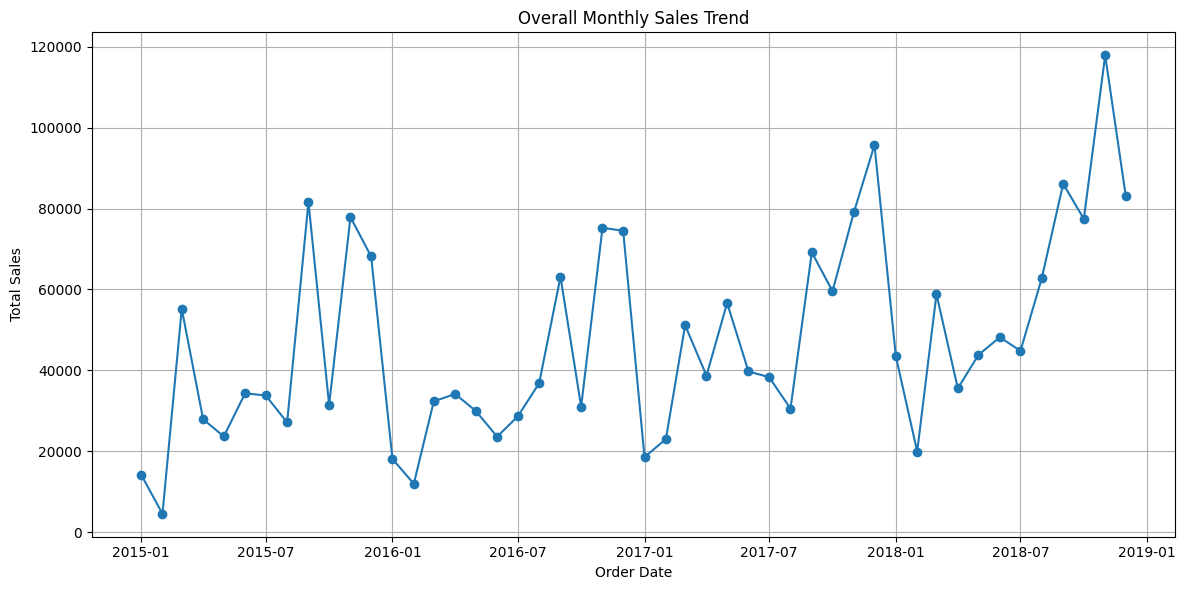

In [12]:
# Plot overall monthly sales trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title('Overall Monthly Sales Trend')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

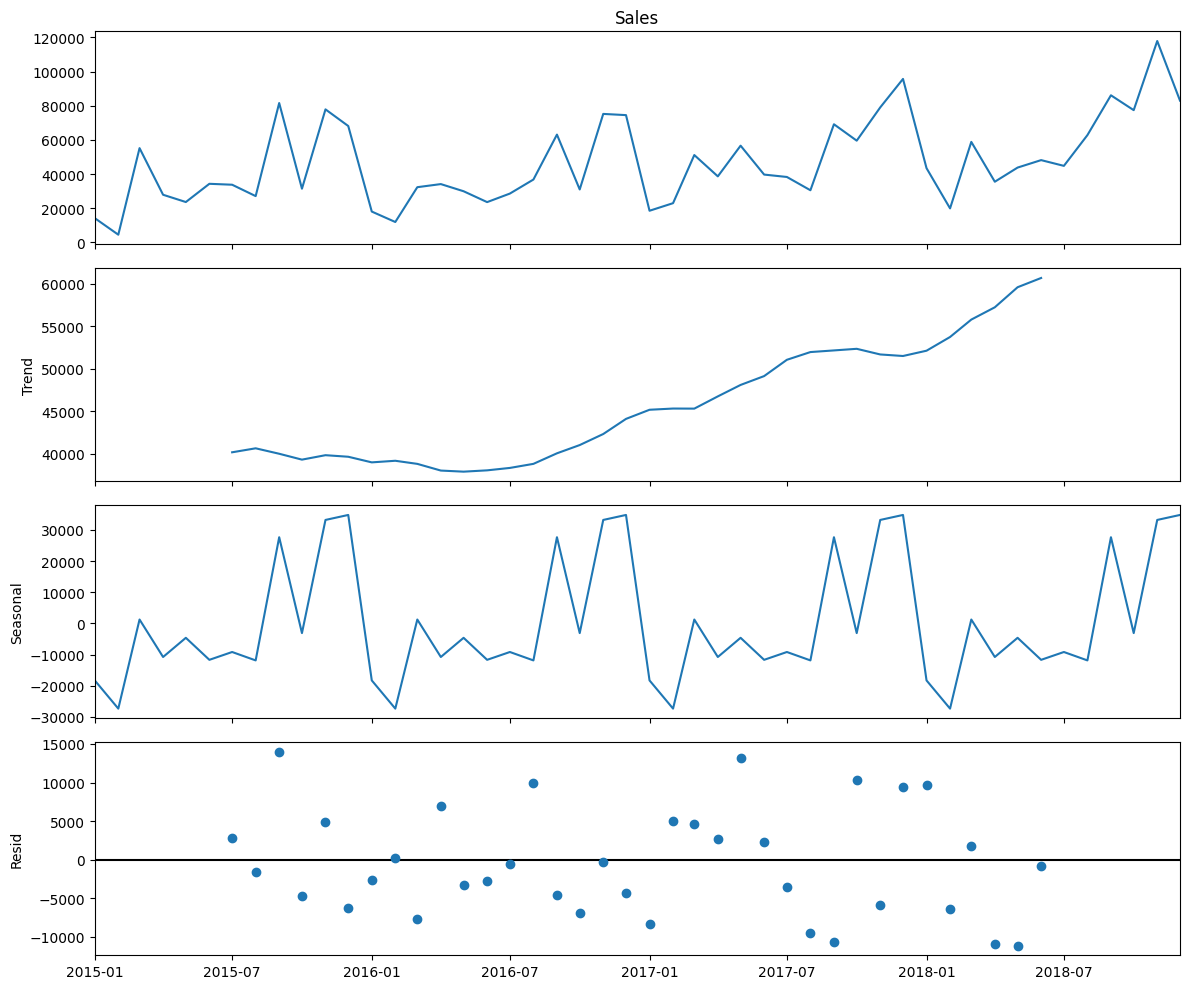

In [13]:
# Apply time series decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

monthly_series = monthly_sales.set_index('Order Date')['Sales']

decomposition = seasonal_decompose(
    monthly_series,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

### Time Series Decomposition Observations

1. **Trend:** The trend component shows an overall upward movement in sales. After a relatively stable period during the earlier years, sales increase noticeably from 2016 onward and reach higher levels toward 2018.

2. **Seasonality:** The seasonal component shows a strong repeating yearly pattern. Similar peaks and declines occur at approximately the same periods each year, indicating significant annual seasonality in sales.

3. **Seasonal Peaks:** The strongest positive seasonal effects appear during the later months of the year, which is consistent with the high sales observed around September, November, and December.

4. **Residual Noise:** The residual component contains both positive and negative fluctuations. The largest residual deviations appear around late 2015 and during parts of 2017, indicating unusual sales movements that are not fully explained by the trend or seasonal pattern.

### Stationarity Check Using Augmented Dickey-Fuller (ADF) Test

Stationarity means that the statistical properties of a time series, such as its mean and variance, remain relatively stable over time. A stationary series is generally more suitable for traditional time series forecasting models such as SARIMA.

In [14]:
# Perform Augmented Dickey-Fuller (ADF) test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_series)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] <= 0.05:
    print("\nThe time series is stationary.")
else:
    print("\nThe time series is non-stationary.")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064

The time series is stationary.


**ADF Test Interpretation:**  
The Augmented Dickey-Fuller test produced an ADF statistic of -4.4161 and a p-value of 0.00028. Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. Therefore, the monthly sales time series is stationary. The statistical properties of the series are sufficiently stable over time for time series modeling. Since the series is already stationary, differencing and re-testing are not required.

## Task 3 — Sales Forecasting Using Three Different Models

In this task, three different forecasting approaches are developed and compared: SARIMA, Prophet, and XGBoost. The models are evaluated using MAE, RMSE, and MAPE to identify the most suitable forecasting model.

### Model 1 — SARIMA

SARIMA is a statistical forecasting model that captures autoregressive patterns, differencing, moving average effects, and seasonal behavior in time series data.

The SARIMA parameters `(1, 0, 1)` and seasonal parameters `(1, 1, 1, 12)` are used. The ADF test showed that the monthly sales series is stationary, so non-seasonal differencing is set to `d=0`. A seasonal period of `12` is selected because the dataset contains monthly sales data with yearly seasonality.

In [15]:
# Split monthly sales data into training and testing sets

train_sarima = monthly_series.iloc[:-3]
test_sarima = monthly_series.iloc[-3:]

print("Training Data Shape:", train_sarima.shape)
print("Testing Data Shape:", test_sarima.shape)

print("\nTesting Period:")
print(test_sarima)

Training Data Shape: (45,)
Testing Data Shape: (3,)

Testing Period:
Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Name: Sales, dtype: float64


In [16]:
# Build and train the SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_sarima,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print("SARIMA Model Trained Successfully")
print(sarima_result.summary())

C:\Users\SANDHYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\SANDHYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA Model Trained Successfully
                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sun, 05 Jul 2026   AIC                            417.362
Time:                                    16:26:59   BIC                            422.084
Sample:                                01-01-2015   HQIC                           418.161
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
m

### SARIMA Parameter Selection

The SARIMA model was configured as SARIMA(1, 0, 1)(1, 1, 1, 12). The non-seasonal parameters p=1 and q=1 were selected to capture short-term autoregressive and moving-average patterns in monthly sales. Since the ADF test indicated that the original sales series was stationary, the non-seasonal differencing parameter d was set to 0.

For the seasonal component, a seasonal period of m=12 was used because the dataset contains monthly sales data with yearly seasonality. Seasonal differencing D=1 was applied to account for recurring annual sales patterns, while P=1 and Q=1 were used to capture seasonal autoregressive and moving-average effects.

In [17]:
# Generate SARIMA predictions for the test period

from sklearn.metrics import mean_absolute_error, mean_squared_error

sarima_test_forecast = sarima_result.get_forecast(steps=3)
sarima_test_pred = sarima_test_forecast.predicted_mean

sarima_mae = mean_absolute_error(test_sarima, sarima_test_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_sarima, sarima_test_pred))
sarima_mape = np.mean(
    np.abs((test_sarima.values - sarima_test_pred.values)
           / test_sarima.values)
) * 100

print("SARIMA Test Predictions:")
print(sarima_test_pred)

print("\nSARIMA Evaluation Metrics:")
print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

SARIMA Test Predictions:
2018-10-01    54758.511874
2018-11-01    88412.595535
2018-12-01    92558.210400
Freq: MS, Name: predicted_mean, dtype: float64

SARIMA Evaluation Metrics:
MAE: 20581.00013025837
RMSE: 22191.26608460345
MAPE: 21.935472965291304


In [18]:
# Fit SARIMA model on the complete monthly sales series

sarima_final_model = SARIMAX(
    monthly_series,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_final_result = sarima_final_model.fit(disp=False)

# Generate 3-month future forecast
sarima_future = sarima_final_result.get_forecast(steps=3)

sarima_future_pred = sarima_future.predicted_mean
sarima_conf_int = sarima_future.conf_int()

print("SARIMA 3-Month Future Forecast:")
print(sarima_future_pred)

print("\nConfidence Intervals:")
print(sarima_conf_int)

C:\Users\SANDHYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\SANDHYA\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA 3-Month Future Forecast:
2019-01-01    45942.740969
2019-02-01    37103.176826
2019-03-01    69034.926533
Freq: MS, Name: predicted_mean, dtype: float64

Confidence Intervals:
             lower Sales   upper Sales
2019-01-01  18855.871856  73029.610081
2019-02-01  10016.917001  64189.436651
2019-03-01  41950.295849  96119.557216


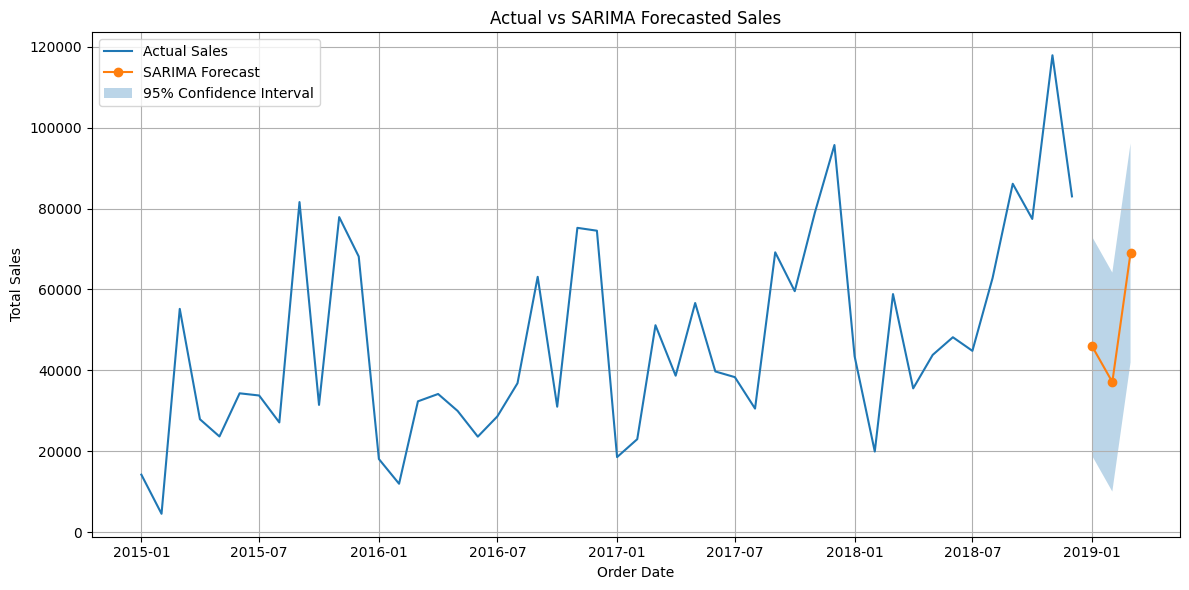

In [19]:
# Plot actual sales and SARIMA future forecast

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_series.index,
    monthly_series.values,
    label='Actual Sales'
)

plt.plot(
    sarima_future_pred.index,
    sarima_future_pred.values,
    marker='o',
    label='SARIMA Forecast'
)

plt.fill_between(
    sarima_conf_int.index,
    sarima_conf_int.iloc[:, 0],
    sarima_conf_int.iloc[:, 1],
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title('Actual vs SARIMA Forecasted Sales')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Model 2 — Prophet

Prophet is a forecasting model designed to capture trends and seasonal patterns in time series data. The monthly sales data is converted into Prophet's required format using `ds` for the date and `y` for the target sales value.

In [20]:
%pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
# Prepare data for Prophet

prophet_data = monthly_sales.rename(
    columns={
        'Order Date': 'ds',
        'Sales': 'y'
    }
)

print("Prophet Data:")
print(prophet_data.head())

print("\nProphet Data Shape:", prophet_data.shape)

Prophet Data:
          ds          y
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303

Prophet Data Shape: (48, 2)


In [22]:
# Train Prophet model and evaluate on the test period

from prophet import Prophet

prophet_train = prophet_data.iloc[:-3]
prophet_test = prophet_data.iloc[-3:]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

prophet_test_future = prophet_test[['ds']]

prophet_test_forecast = prophet_model.predict(prophet_test_future)

prophet_test_pred = prophet_test_forecast['yhat'].values

prophet_mae = mean_absolute_error(
    prophet_test['y'],
    prophet_test_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test['y'],
        prophet_test_pred
    )
)

prophet_mape = np.mean(
    np.abs(
        (prophet_test['y'].values - prophet_test_pred)
        / prophet_test['y'].values
    )
) * 100

print("Prophet Test Predictions:")
print(prophet_test_forecast[['ds', 'yhat']])

print("\nProphet Evaluation Metrics:")
print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

Importing plotly failed. Interactive plots will not work.
16:27:03 - cmdstanpy - INFO - Chain [1] start processing
16:27:03 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test Predictions:
          ds          yhat
0 2018-10-01  67685.521257
1 2018-11-01  88817.229476
2 2018-12-01  88361.823427

Prophet Evaluation Metrics:
MAE: 14738.323364461845
RMSE: 17997.787377294782
MAPE: 14.572702793011413


In [23]:
# Fit Prophet model on the complete dataset

prophet_final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_final_model.fit(prophet_data)

# Create future dates for the next 3 months
prophet_future = prophet_final_model.make_future_dataframe(
    periods=3,
    freq='MS'
)

# Generate forecast
prophet_forecast = prophet_final_model.predict(prophet_future)

prophet_future_forecast = prophet_forecast[
    prophet_forecast['ds'] > prophet_data['ds'].max()
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

print("Prophet 3-Month Future Forecast:")
print(prophet_future_forecast)

16:27:03 - cmdstanpy - INFO - Chain [1] start processing
16:27:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet 3-Month Future Forecast:
           ds          yhat    yhat_lower    yhat_upper
48 2019-01-01  42134.431344  35091.062712  49208.322160
49 2019-02-01  30304.162466  23567.283265  36952.445719
50 2019-03-01  84306.331904  77303.157535  90981.222428


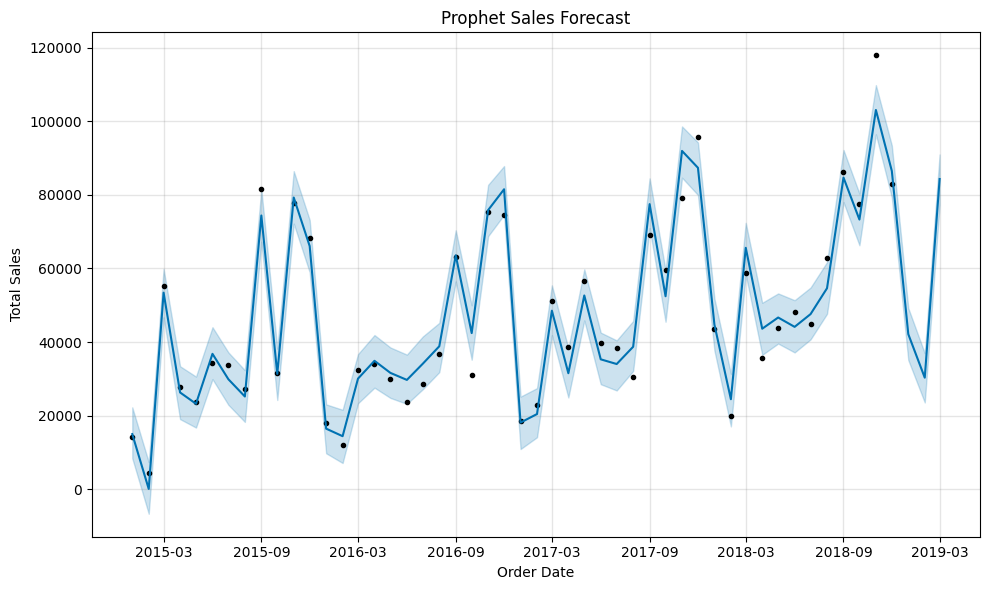

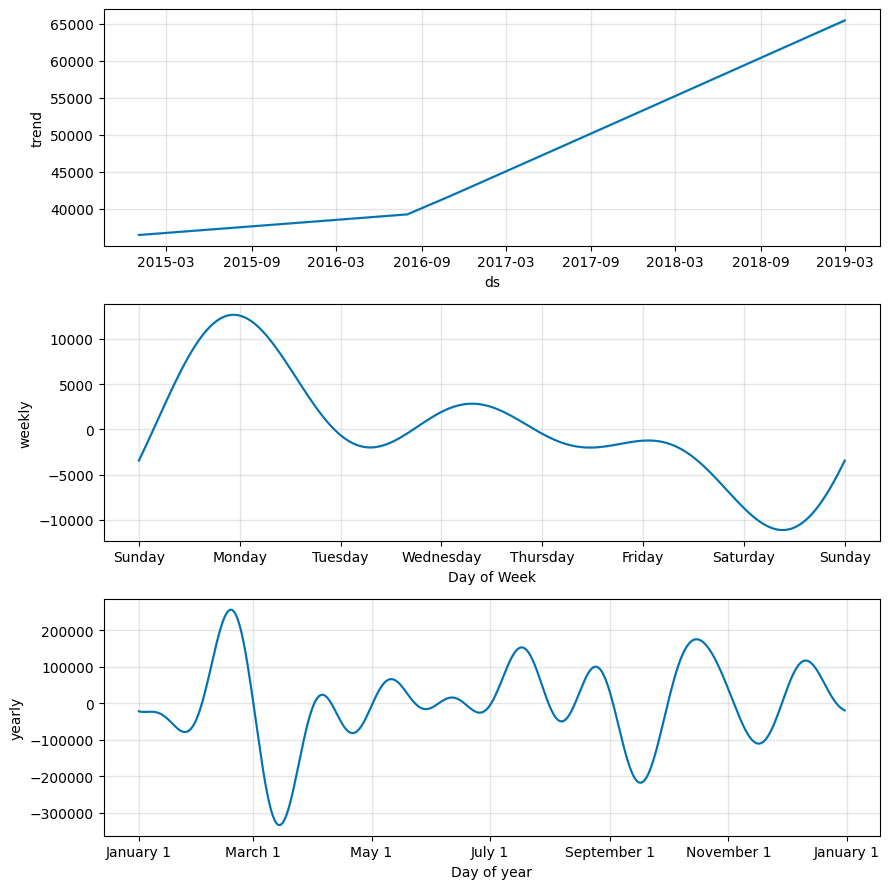

In [24]:
# Plot Prophet forecast

fig1 = prophet_final_model.plot(prophet_forecast)
plt.title('Prophet Sales Forecast')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Plot Prophet trend and seasonality components

fig2 = prophet_final_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

### Prophet Trend and Seasonality Observations

1. **Trend:** The Prophet trend component shows an overall increase in monthly sales. The growth becomes stronger from the second half of 2016 and continues upward toward 2019.

2. **Weekly Seasonality:** The weekly component shows variations across different days of the week. Monday has the strongest positive effect, while Saturday shows the largest negative seasonal effect.

3. **Yearly Seasonality:** The yearly component indicates strong seasonal fluctuations throughout the year. Positive seasonal peaks appear during specific periods, particularly around late February, July, October, and December.

4. **Forecast Pattern:** The Prophet forecast captures both the upward sales trend and recurring seasonal fluctuations. The forecast uncertainty interval represents the possible range of future sales values.

### Model 3 — XGBoost

XGBoost is a machine learning-based forecasting approach. Since machine learning models do not automatically understand time order, lag features, a rolling mean, and calendar-based features are created from the monthly sales series.

In [52]:
# Create features for XGBoost forecasting

xgb_data = monthly_sales.copy()

xgb_data['Lag_1'] = xgb_data['Sales'].shift(1)
xgb_data['Lag_2'] = xgb_data['Sales'].shift(2)
xgb_data['Lag_3'] = xgb_data['Sales'].shift(3)

xgb_data['Rolling_Mean_3'] = (
    xgb_data['Sales']
    .shift(1)
    .rolling(window=3)
    .mean()
)

xgb_data['Month'] = xgb_data['Order Date'].dt.month
xgb_data['Quarter'] = xgb_data['Order Date'].dt.quarter

# Create Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 1  # Winter
    elif month in [3, 4, 5]:
        return 2  # Spring
    elif month in [6, 7, 8]:
        return 3  # Summer
    else:
        return 4  # Autumn

xgb_data['Season'] = xgb_data['Month'].apply(get_season)

xgb_data = xgb_data.dropna().reset_index(drop=True)

print("XGBoost Feature Data:")
print(xgb_data.head())

print("\nXGBoost Data Shape:", xgb_data.shape)

XGBoost Feature Data:
  Order Date       Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean_3  \
0 2015-04-01  27906.8550  55205.7970   4519.8920  14205.707    24643.798667   
1 2015-05-01  23644.3030  27906.8550  55205.7970   4519.892    29210.848000   
2 2015-06-01  34322.9356  23644.3030  27906.8550  55205.797    35585.651667   
3 2015-07-01  33781.5430  34322.9356  23644.3030  27906.855    28624.697867   
4 2015-08-01  27117.5365  33781.5430  34322.9356  23644.303    30582.927200   

   Month  Quarter  Season  
0      4        2       2  
1      5        2       2  
2      6        2       3  
3      7        3       3  
4      8        3       3  

XGBoost Data Shape: (45, 9)


In [58]:
# Time-based train-test split for XGBoost

feature_columns = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Rolling_Mean_3',
    'Month',
    'Quarter',
    'Season'
]

X = xgb_data[feature_columns]
y = xgb_data['Sales']

X_train_xgb = X.iloc[:-3]
X_test_xgb = X.iloc[-3:]

y_train_xgb = y.iloc[:-3]
y_test_xgb = y.iloc[-3:]

print("Training Data Shape:", X_train_xgb.shape)
print("Testing Data Shape:", X_test_xgb.shape)

print("\nTesting Sales:")
print(y_test_xgb)

Training Data Shape: (42, 7)
Testing Data Shape: (3, 7)

Testing Sales:
42     77448.1312
43    117938.1550
44     83030.3888
Name: Sales, dtype: float64


In [59]:
# Train and evaluate the XGBoost model

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_test_pred = xgb_model.predict(X_test_xgb)

xgb_mae = mean_absolute_error(y_test_xgb, xgb_test_pred)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test_xgb, xgb_test_pred)
)

xgb_mape = np.mean(
    np.abs(
        (y_test_xgb.values - xgb_test_pred)
        / y_test_xgb.values
    )
) * 100

print("XGBoost Test Predictions:")
print(xgb_test_pred)

print("\nXGBoost Evaluation Metrics:")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

XGBoost Test Predictions:
[65726.734 85343.17  65525.305]

XGBoost Evaluation Metrics:
MAE: 20607.154687500002
RMSE: 22407.231260122662
MAPE: 21.28486932639092


In [61]:
# Forecast next 3 months using XGBoost

xgb_final_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_final_model.fit(X, y)

sales_history = list(xgb_data['Sales'])

xgb_future_predictions = []
xgb_future_dates = []

last_date = xgb_data['Order Date'].iloc[-1]

for i in range(1, 4):

    future_date = last_date + pd.DateOffset(months=i)

    lag_1 = sales_history[-1]
    lag_2 = sales_history[-2]
    lag_3 = sales_history[-3]

    rolling_mean_3 = np.mean(sales_history[-3:])

    month = future_date.month
    quarter = future_date.quarter
    season = get_season(month)

    future_features = pd.DataFrame({
        'Lag_1': [lag_1],
        'Lag_2': [lag_2],
        'Lag_3': [lag_3],
        'Rolling_Mean_3': [rolling_mean_3],
        'Month': [month],
        'Quarter': [quarter],
        'Season': [season]
    })

    prediction = xgb_final_model.predict(future_features)[0]

    xgb_future_predictions.append(prediction)
    xgb_future_dates.append(future_date)

    sales_history.append(prediction)

xgb_future_forecast = pd.DataFrame({
    'Order Date': xgb_future_dates,
    'Forecasted Sales': xgb_future_predictions
})

print("XGBoost 3-Month Future Forecast:")
print(xgb_future_forecast)

XGBoost 3-Month Future Forecast:
  Order Date  Forecasted Sales
0 2019-01-01      43513.898438
1 2019-02-01      22613.105469
2 2019-03-01      56422.648438


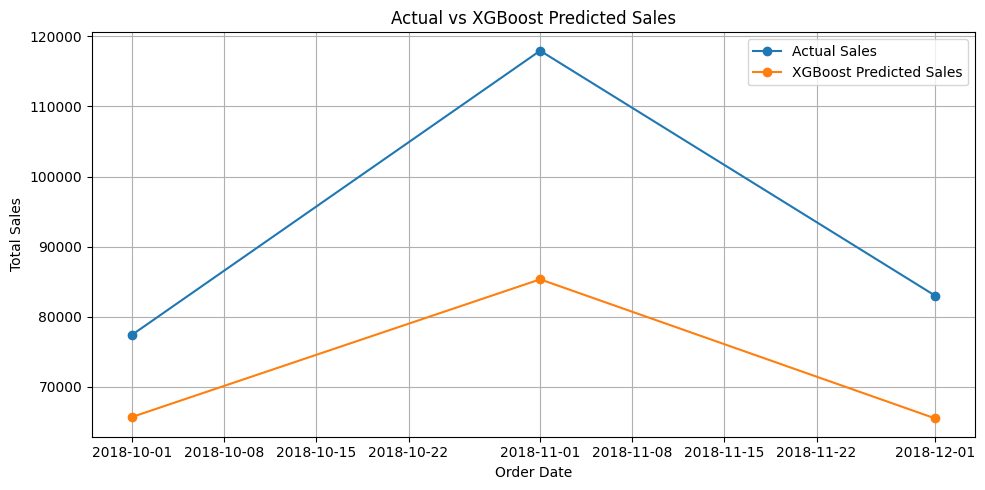

In [62]:
# Plot actual vs XGBoost predicted sales

plt.figure(figsize=(10, 5))

plt.plot(
    xgb_data['Order Date'].iloc[-3:],
    y_test_xgb.values,
    marker='o',
    label='Actual Sales'
)

plt.plot(
    xgb_data['Order Date'].iloc[-3:],
    xgb_test_pred,
    marker='o',
    label='XGBoost Predicted Sales'
)

plt.title('Actual vs XGBoost Predicted Sales')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [63]:
# Compare SARIMA, Prophet, and XGBoost models

model_comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    'RMSE': [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    'MAPE (%)': [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],
    'Month 1 Forecast': [
        sarima_future_pred.iloc[0],
        prophet_future_forecast['yhat'].iloc[0],
        xgb_future_predictions[0]
    ],
    'Month 2 Forecast': [
        sarima_future_pred.iloc[1],
        prophet_future_forecast['yhat'].iloc[1],
        xgb_future_predictions[1]
    ],
    'Month 3 Forecast': [
        sarima_future_pred.iloc[2],
        prophet_future_forecast['yhat'].iloc[2],
        xgb_future_predictions[2]
    ]
})

model_comparison = model_comparison.round(2)

print("Model Comparison Table:")
print(model_comparison)

Model Comparison Table:
     Model       MAE      RMSE  MAPE (%)  Month 1 Forecast  Month 2 Forecast  \
0   SARIMA  20581.00  22191.27     21.94          45942.74          37103.18   
1  Prophet  14738.32  17997.79     14.57          42134.43          30304.16   
2  XGBoost  20607.15  22407.23     21.28          43513.90          22613.11   

   Month 3 Forecast  
0          69034.93  
1          84306.33  
2          56422.65  


## Task 4 — Product Category & Region Level Forecasting

The best-performing Prophet model is applied separately to Furniture, Technology, Office Supplies, West region, and East region sales to forecast the next three months.

In [38]:
# Define categories and regions for segment-level forecasting

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

print("Segments prepared successfully:")

for segment_name, segment_data in segments.items():
    print(segment_name, "-", segment_data.shape)

Segments prepared successfully:
Furniture - (2078, 25)
Technology - (1813, 25)
Office Supplies - (5909, 25)
West Region - (3140, 25)
East Region - (2785, 25)


In [39]:
# Generate 3-month Prophet forecasts for all 5 segments

segment_forecasts = []

for segment_name, segment_data in segments.items():

    segment_monthly = (
        segment_data
        .set_index('Order Date')['Sales']
        .resample('MS')
        .sum()
        .reset_index()
    )

    prophet_segment_data = segment_monthly.rename(
        columns={
            'Order Date': 'ds',
            'Sales': 'y'
        }
    )

    segment_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    segment_model.fit(prophet_segment_data)

    segment_future = segment_model.make_future_dataframe(
        periods=3,
        freq='MS'
    )

    segment_forecast = segment_model.predict(segment_future)

    future_3_months = segment_forecast.tail(3)[
        ['ds', 'yhat']
    ].copy()

    future_3_months['Segment'] = segment_name

    segment_forecasts.append(future_3_months)

segment_forecast_results = pd.concat(
    segment_forecasts,
    ignore_index=True
)

segment_forecast_results['yhat'] = (
    segment_forecast_results['yhat'].clip(lower=0)
)

segment_forecast_results = segment_forecast_results[
    ['Segment', 'ds', 'yhat']
]

print("3-Month Forecast for Categories and Regions:")
print(segment_forecast_results)

16:57:23 - cmdstanpy - INFO - Chain [1] start processing
16:57:23 - cmdstanpy - INFO - Chain [1] done processing
16:57:24 - cmdstanpy - INFO - Chain [1] start processing
16:57:24 - cmdstanpy - INFO - Chain [1] done processing
16:57:25 - cmdstanpy - INFO - Chain [1] start processing
16:57:25 - cmdstanpy - INFO - Chain [1] done processing
16:57:26 - cmdstanpy - INFO - Chain [1] start processing
16:57:26 - cmdstanpy - INFO - Chain [1] done processing
16:57:26 - cmdstanpy - INFO - Chain [1] start processing
16:57:27 - cmdstanpy - INFO - Chain [1] done processing


3-Month Forecast for Categories and Regions:
            Segment         ds          yhat
0         Furniture 2019-01-01  12703.027817
1         Furniture 2019-02-01   7686.983287
2         Furniture 2019-03-01  16989.046332
3        Technology 2019-01-01  13815.845691
4        Technology 2019-02-01  11356.808224
5        Technology 2019-03-01  42215.823823
6   Office Supplies 2019-01-01  14508.928486
7   Office Supplies 2019-02-01  12500.104406
8   Office Supplies 2019-03-01  19421.521948
9       West Region 2019-01-01  14626.053312
10      West Region 2019-02-01  11907.970620
11      West Region 2019-03-01  26432.585991
12      East Region 2019-01-01   9412.424813
13      East Region 2019-02-01  10128.314904
14      East Region 2019-03-01  14478.008752


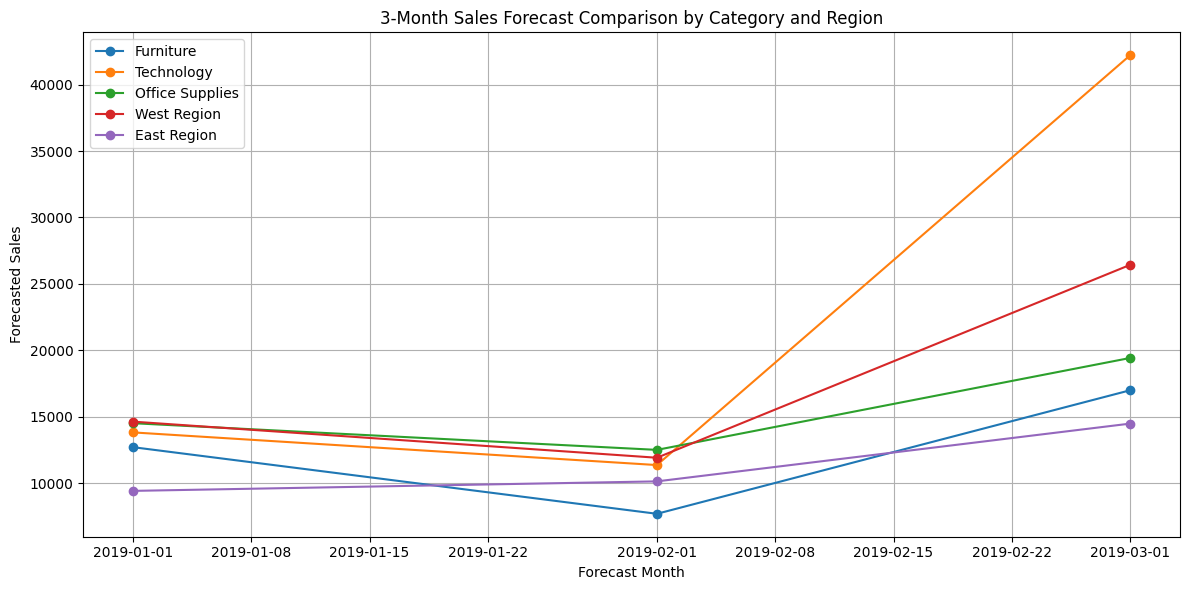

In [40]:
# Plot all 5 segment forecasts on one comparison chart

plt.figure(figsize=(12, 6))

for segment in segment_forecast_results['Segment'].unique():

    segment_plot = segment_forecast_results[
        segment_forecast_results['Segment'] == segment
    ]

    plt.plot(
        segment_plot['ds'],
        segment_plot['yhat'],
        marker='o',
        label=segment
    )

plt.title('3-Month Sales Forecast Comparison by Category and Region')
plt.xlabel('Forecast Month')
plt.ylabel('Forecasted Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
# Calculate forecasted growth for each category and region

segment_growth = (
    segment_forecast_results
    .sort_values(['Segment', 'ds'])
    .groupby('Segment')
    .apply(
        lambda x: (
            (x['yhat'].iloc[-1] - x['yhat'].iloc[0])
            / x['yhat'].iloc[0]
        ) * 100
    )
    .sort_values(ascending=False)
)

print("Forecasted Growth by Category and Region (%):")
print(segment_growth)

print("\nStrongest Upcoming Growth:")
print(segment_growth.idxmax())

Forecasted Growth by Category and Region (%):
Segment
Technology         205.560910
West Region         80.722615
East Region         53.818055
Office Supplies     33.859106
Furniture           33.740133
dtype: float64

Strongest Upcoming Growth:
Technology


### Forecast Growth Observation

Technology shows the strongest upcoming sales growth of approximately 205.56%, increasing from a forecasted sales value of $13,815.85 in January 2019 to $42,215.82 in March 2019. The West Region shows the second-highest forecasted growth of 80.72%, followed by the East Region at 53.82%. Office Supplies and Furniture show moderate forecasted growth of 33.86% and 33.74%, respectively. Therefore, Technology should receive greater attention in future sales planning and inventory allocation.

## Task 5 — Anomaly Detection in Sales

This task identifies unusual monthly sales patterns using Isolation Forest and Z-Score methods.

In [43]:
# Prepare monthly sales data for anomaly detection

anomaly_data = monthly_sales.copy()

print("Monthly Sales Data for Anomaly Detection:")
print(anomaly_data.head())

print("\nData Shape:")
print(anomaly_data.shape)

Monthly Sales Data for Anomaly Detection:
  Order Date      Sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303

Data Shape:
(48, 2)


In [44]:
# Detect sales anomalies using Isolation Forest

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomaly_data['Isolation_Forest'] = (
    isolation_forest.fit_predict(anomaly_data[['Sales']])
)

isolation_anomalies = anomaly_data[
    anomaly_data['Isolation_Forest'] == -1
]

print("Isolation Forest Anomalies:")
print(isolation_anomalies[['Order Date', 'Sales']])

print("\nNumber of Isolation Forest Anomalies:")
print(len(isolation_anomalies))

Isolation Forest Anomalies:
   Order Date       Sales
1  2015-02-01    4519.892
35 2017-12-01   95739.121
46 2018-11-01  117938.155

Number of Isolation Forest Anomalies:
3


In [45]:
# Detect sales anomalies using Z-Score method

from scipy.stats import zscore

anomaly_data['Z_Score'] = zscore(anomaly_data['Sales'])

zscore_anomalies = anomaly_data[
    anomaly_data['Z_Score'].abs() > 2
]

print("Z-Score Anomalies:")
print(
    zscore_anomalies[
        ['Order Date', 'Sales', 'Z_Score']
    ]
)

print("\nNumber of Z-Score Anomalies:")
print(len(zscore_anomalies))

Z-Score Anomalies:
   Order Date       Sales   Z_Score
46 2018-11-01  117938.155  2.865334

Number of Z-Score Anomalies:
1


Anomaly Detection Comparison:
   Order Date       Sales  Isolation_Anomaly  Z_Score_Anomaly
1  2015-02-01    4519.892               True            False
35 2017-12-01   95739.121               True            False
46 2018-11-01  117938.155               True             True


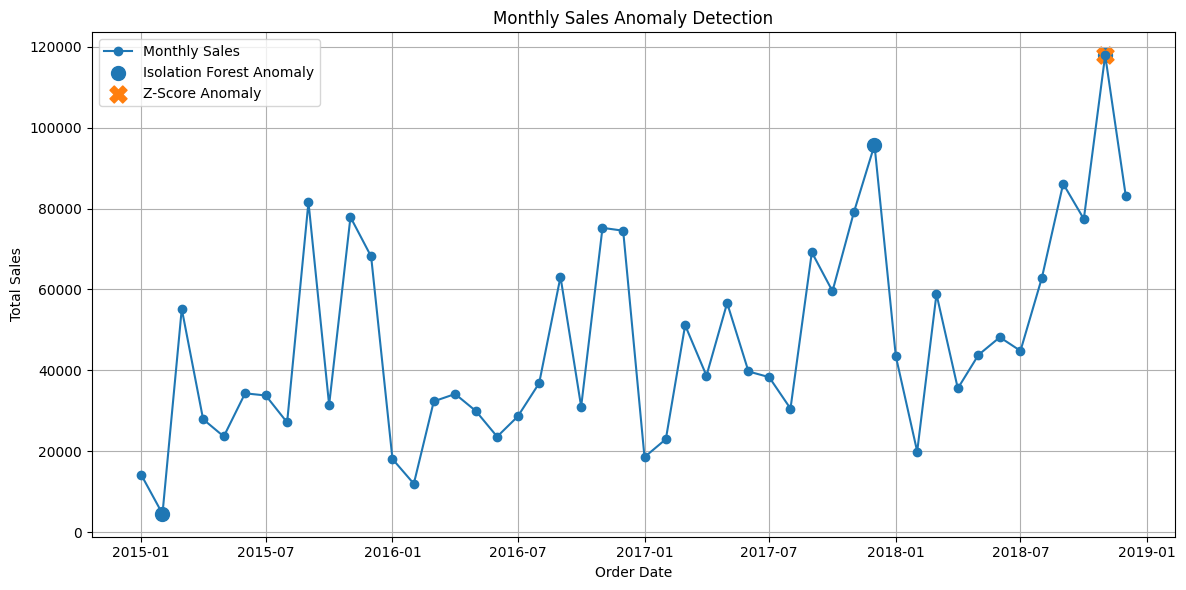

In [46]:
# Compare Isolation Forest and Z-Score anomalies

anomaly_data['Z_Score_Anomaly'] = (
    anomaly_data['Z_Score'].abs() > 2
)

anomaly_data['Isolation_Anomaly'] = (
    anomaly_data['Isolation_Forest'] == -1
)

print("Anomaly Detection Comparison:")
print(
    anomaly_data[
        anomaly_data['Z_Score_Anomaly']
        | anomaly_data['Isolation_Anomaly']
    ][
        [
            'Order Date',
            'Sales',
            'Isolation_Anomaly',
            'Z_Score_Anomaly'
        ]
    ]
)

# Plot anomalies

plt.figure(figsize=(12, 6))

plt.plot(
    anomaly_data['Order Date'],
    anomaly_data['Sales'],
    marker='o',
    label='Monthly Sales'
)

plt.scatter(
    isolation_anomalies['Order Date'],
    isolation_anomalies['Sales'],
    s=100,
    label='Isolation Forest Anomaly'
)

plt.scatter(
    zscore_anomalies['Order Date'],
    zscore_anomalies['Sales'],
    marker='X',
    s=150,
    label='Z-Score Anomaly'
)

plt.title('Monthly Sales Anomaly Detection')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Anomaly Detection Observation and Business Explanation

Isolation Forest detected three unusual monthly sales observations: February 2015 with sales of $4,519.89, December 2017 with sales of $95,739.12, and November 2018 with sales of $117,938.16. The Z-Score method identified November 2018 as a significant anomaly with a Z-Score of 2.87.

The unusually low sales in February 2015 may indicate weak seasonal demand, fewer customer orders, or temporary operational factors. The high sales observed in December 2017 and November 2018 may be associated with seasonal demand, holiday purchasing, promotional campaigns, or large customer orders. November 2018 was detected by both methods, making it the strongest sales anomaly in the dataset.

From a business perspective, unusually high sales periods should be investigated to identify successful products, regions, or promotional activities that can be repeated. Low-sales anomalies should be reviewed for inventory, customer demand, and operational issues.

# Task 6 – Product Demand Segmentation using Clustering

In [3]:
import pandas as pd

df = pd.read_csv("train.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [4]:
# Product Demand Segmentation

import pandas as pd
import numpy as np

# Monthly sales by Sub-Category
monthly_sales = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()

# Total Sales
total_sales = df.groupby('Sub-Category')['Sales'].sum()

# Sales Volatility
sales_volatility = monthly_sales.groupby('Sub-Category')['Sales'].std()

# Average Order Value
avg_order_value = df.groupby('Sub-Category')['Sales'].mean()

# Sales Growth Rate (Year-over-Year)
yearly_sales = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack(fill_value=0)

growth_rate = ((yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0]) /
               yearly_sales.iloc[:, 0]) * 100

# Final Feature Table
product_features = pd.DataFrame({
    'Total_Sales': total_sales,
    'Sales_Growth_Rate': growth_rate,
    'Sales_Volatility': sales_volatility,
    'Average_Order_Value': avg_order_value
})

product_features = product_features.fillna(0)

product_features.head()

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [6]:
from sklearn.preprocessing import StandardScaler

# Scale Features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(product_features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=product_features.columns,
    index=product_features.index
)

scaled_df.head()

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,0.315986,0.603161,0.085085,-0.363549
Appliances,-0.288176,0.783458,-0.347062,-0.345202
Art,-1.078397,-0.248947,-1.196761,-0.676171
Binders,0.679509,-0.104892,0.807765,-0.505405
Bookcases,-0.194919,-0.247187,-0.119821,0.125325


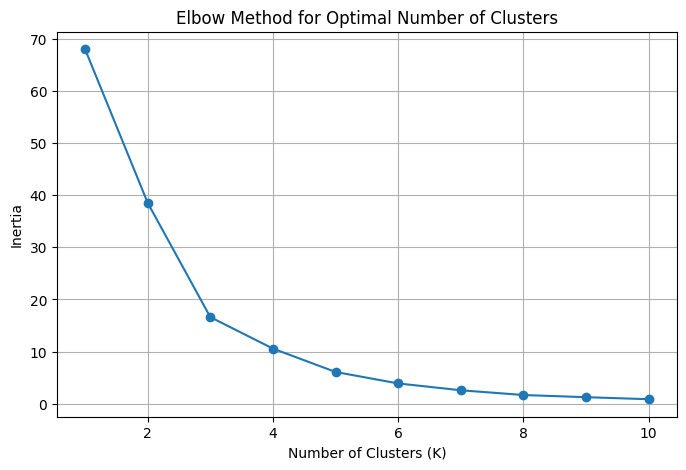

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [8]:
# Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_features['Cluster'] = kmeans.fit_predict(scaled_df)

product_features.head()

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1


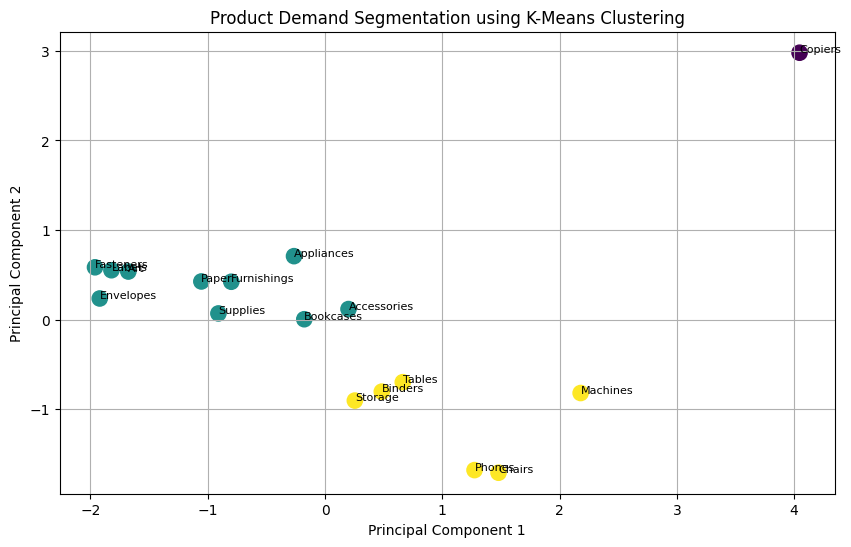

In [9]:
from sklearn.decomposition import PCA

# Reduce to 2 Dimensions
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_df)

plt.figure(figsize=(10,6))

plt.scatter(
    pca_features[:,0],
    pca_features[:,1],
    c=product_features['Cluster'],
    cmap='viridis',
    s=120
)

for i, txt in enumerate(product_features.index):
    plt.annotate(txt, (pca_features[i,0], pca_features[i,1]), fontsize=8)

plt.title("Product Demand Segmentation using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [10]:
product_features

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1
Chairs,322822.7310,20.954677,4407.232960,531.833165,2
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1
Fasteners,3001.9600,30.468364,48.742229,14.027850,1


In [11]:
cluster_names = {
    0: "High Growth Premium Products",
    1: "Stable Demand Products",
    2: "High Volume Products"
}

product_features["Cluster_Name"] = product_features["Cluster"].map(cluster_names)

product_features

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster,Cluster_Name
Sub-Category,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,Stable Demand Products
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,Stable Demand Products
Art,26705.4100,49.649531,330.488343,34.019631,1,Stable Demand Products
Binders,200028.7850,65.778638,3848.223648,134.067550,2,High Volume Products
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,Stable Demand Products
Chairs,322822.7310,20.954677,4407.232960,531.833165,2,High Volume Products
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,High Growth Premium Products
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,Stable Demand Products
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,Stable Demand Products


In [12]:
cluster_summary = product_features.groupby("Cluster_Name").mean(numeric_only=True)

cluster_summary

,Total_Sales,Sales_Growth_Rate,Sales_Volatility,Average_Order_Value,Cluster
Cluster_Name,,,,,
High Growth Premium Products,146248.09400,479.729510,5500.774391,2215.880212,0.0
High Volume Products,243671.10250,27.323655,3992.982732,599.193752,2.0
Stable Demand Products,65326.20737,67.421837,1186.287889,150.189900,1.0


## Product Demand Segmentation Observations

The Elbow Method indicated that **3 clusters** were optimal for product demand segmentation.

- **High Growth Premium Products** include products with high sales growth and higher average order values, making them suitable for premium inventory planning.
- **Stable Demand Products** show consistent sales performance with moderate growth and lower volatility, making them ideal for regular inventory replenishment.
- **High Volume Products** generate high overall sales and require sufficient stock availability to avoid stock-outs during peak demand periods.

Overall, this clustering approach helps identify different demand patterns across product sub-categories, enabling better inventory management and business decision-making.

## Recommended Stocking Strategy

### High Growth Premium Products
- Increase inventory gradually to meet rising demand.
- Focus on premium product promotion and targeted marketing.

### Stable Demand Products
- Maintain consistent inventory levels.
- Use periodic replenishment based on historical demand.

### High Volume Products
- Keep higher safety stock to prevent stock-outs.
- Prioritize warehouse space and continuous monitoring during seasonal demand.